In [1]:
import mesa
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

# === SCALE CONSTANTS (1m cells) ===
CELL_SIZE_M = 1.0
SECONDS_PER_STEP = 1.0

# === GRID DIMENSIONS (cells) ===
WIDTH = 58    # cols, west -> east
HEIGHT = 67   # rows, north -> south

walkable = set()
exits = set()
spawn400 = set()
spawn401 = set()
dead = set()

def fill(r0, r1, c0, c1, target_set, also_walkable=True):
    """Add rows r0..r1, cols c0..c1 (inclusive) to target_set.
    Cells stored as (col, row) = (x, y) for Mesa."""
    for r in range(r0, r1 + 1):
        for c in range(c0, c1 + 1):
            if 0 <= r < HEIGHT and 0 <= c < WIDTH:
                target_set.add((c, r))
                if also_walkable:
                    walkable.add((c, r))

# Assembly rooms (spawn zones, walkable)
fill(44, 66, 42, 57, spawn400)        # RCF 400 (east, large)
fill(59, 66, 18, 32, spawn401)        # RCF 401 (lower-west)

# Circulation open area
fill(44, 58, 22, 41, walkable)

# North corridor to Stair 2
fill(20, 43, 30, 34, walkable)
fill(20, 24, 30, 44, walkable)
fill(8, 19, 30, 34, walkable)
fill(8, 12, 18, 31, walkable)

# West nook to Stair 3 / bathrooms
fill(46, 54, 18, 21, walkable)

# Exits (stair entries, walkable)
fill(8, 12, 15, 17, exits)            # Stair 2
fill(55, 58, 18, 25, exits)           # Stair 3

# Non-walkable obstacles
fill(14, 19, 40, 44, dead, also_walkable=False)   # elevators
fill(46, 49, 14, 21, dead, also_walkable=False)   # bathrooms
fill(59, 66, 33, 41, dead, also_walkable=False)   # deadspace between rooms

print(f"Walkable cells: {len(walkable)}")
print(f"Exit cells:     {len(exits)}")
print(f"RCF 400 spawn:  {len(spawn400)} cells")
print(f"RCF 401 spawn:  {len(spawn401)} cells")
print(f"Deadspace:      {len(dead)} cells")

Walkable cells: 1145
Exit cells:     47
RCF 400 spawn:  368 cells
RCF 401 spawn:  120 cells
Deadspace:      134 cells


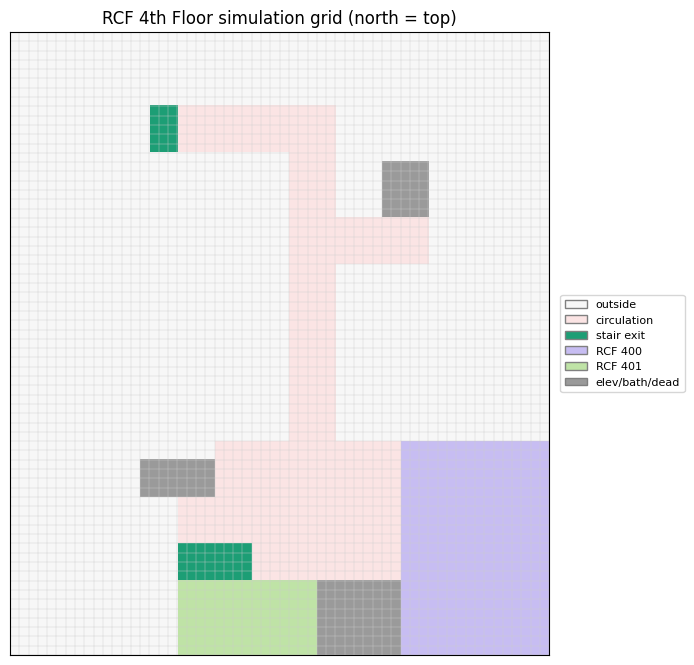

In [2]:
def render_floor(occupant_positions=None):
    arr = np.zeros((HEIGHT, WIDTH), dtype=int)
    for (c, r) in walkable:   arr[r][c] = 1
    for (c, r) in spawn400:   arr[r][c] = 3
    for (c, r) in spawn401:   arr[r][c] = 4
    for (c, r) in exits:      arr[r][c] = 2
    for (c, r) in dead:       arr[r][c] = 5

    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
    colors = ['#f7f7f7', '#fbe4e4', '#1d9e75', '#c7bdf2', '#bfe3a6', '#9a9a9a']
    labels = ['outside', 'circulation', 'stair exit', 'RCF 400', 'RCF 401', 'elev/bath/dead']
    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(7, 8))
    ax.imshow(arr, cmap=cmap, vmin=0, vmax=5, origin='upper', interpolation='nearest')
    for x in range(WIDTH + 1):  ax.axvline(x - 0.5, color='#cccccc', linewidth=0.3)
    for y in range(HEIGHT + 1): ax.axhline(y - 0.5, color='#cccccc', linewidth=0.3)
    if occupant_positions:
        xs = [p[0] for p in occupant_positions]
        ys = [p[1] for p in occupant_positions]
        ax.scatter(xs, ys, s=8, c='#333333', alpha=0.7, zorder=5)
    ax.set_title('RCF 4th Floor simulation grid (north = top)')
    ax.set_xticks([]); ax.set_yticks([])
    legend = [Patch(facecolor=colors[i], edgecolor='gray', label=labels[i]) for i in range(len(labels))]
    ax.legend(handles=legend, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()

render_floor()

In [3]:
def compute_distance_field(walkable, exits):
    """BFS from all exits. Returns {cell: steps-to-nearest-exit}, routing
    only through walkable cells."""
    distance = {}
    queue = deque()
    for cell in exits:
        distance[cell] = 0
        queue.append(cell)
    directions = [(-1,-1),(0,-1),(1,-1),(-1,0),(1,0),(-1,1),(0,1),(1,1)]
    while queue:
        cx, cy = queue.popleft()
        current = distance[(cx, cy)]
        for dx, dy in directions:
            nb = (cx + dx, cy + dy)
            if nb in walkable and nb not in distance:
                distance[nb] = current + 1
                queue.append(nb)
    return distance

distance_field = compute_distance_field(walkable, exits)
print(f"Cells with a path to an exit: {len(distance_field)} / {len(walkable)} walkable")
unreachable = walkable - set(distance_field.keys())
print(f"Unreachable walkable cells: {len(unreachable)}")
print(f"Max distance to an exit: {max(distance_field.values())} steps")

Cells with a path to an exit: 1145 / 1145 walkable
Unreachable walkable cells: 0
Max distance to an exit: 32 steps


In [4]:
class OccupantAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.state = "moving"

        # ============================================================
        # CHANGED: pre-movement time is now a right-skewed WEIBULL draw
        # (was: self.random.randint(0, 30) uniform).
        # Real pre-movement data fits a Weibull distribution (Gwynne/Boyce,
        # school-drill validation studies): most occupants react fairly
        # quickly, with a tail of slow reactors. Parameters below are for
        # an alert assembly occupancy (median ~28s, tail toward ~120s+).
        # weibullvariate(alpha=scale, beta=shape).
        weibull_shape = 1.8
        weibull_scale = 35.0
        self.reaction_delay = int(self.random.weibullvariate(weibull_scale, weibull_shape))
        # ============================================================

        self.steps_waited = 0
        self.target_stair = "stair3"  # default; the model reassigns half to stair2

    def step(self):
        if self.state == "escaped":
            return
        if self.steps_waited < self.reaction_delay:
            self.steps_waited += 1
            return

        my_field = self.model.dist_to[self.target_stair]   # my assigned stair's field

        # On an exit cell for MY stair? Escape if the door has budget, else wait.
        if self.pos in self.model.exits and self.model.cell_to_door[self.pos] == self.target_stair:
            door = self.target_stair
            if self.model.door_budget[door] >= 1.0:
                self.model.door_budget[door] -= 1.0
                self.state = "escaped"
                self.model.escaped_count += 1
                self.model.door_escape_count[door] += 1
                self.model.grid.remove_agent(self)
            return

        # Move downhill on MY assigned stair's distance field.
        neighbors = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=False)
        candidates = [c for c in neighbors if c in my_field]
        if candidates:
            my_dist = my_field.get(self.pos, float("inf"))
            best = min(candidates, key=lambda c: my_field[c])
            if my_field[best] < my_dist:
                self.model.grid.move_agent(self, best)

In [5]:
class RCFFloorModel(mesa.Model):
    def __init__(self, n_400=304, n_401=87, seed=None):
        super().__init__(seed=seed)
        self.walkable = walkable
        self.exits = exits
        self.grid = mesa.space.MultiGrid(WIDTH, HEIGHT, torus=False)

        # Per-stair distance fields (computed from the two stair groups).
        stair2_cells = {cell for cell in exits if cell[1] < 30}
        stair3_cells = {cell for cell in exits if cell[1] >= 30}
        self.dist_to = {
            "stair2": compute_distance_field(walkable, stair2_cells),
            "stair3": compute_distance_field(walkable, stair3_cells),
        }

        # Group exit cells into doors.
        self.cell_to_door = {}
        for (c, r) in exits:
            self.cell_to_door[(c, r)] = "stair2" if r < 30 else "stair3"

        DOOR_FLOW = 0.8
        self.door_flow_per_step = {"stair2": DOOR_FLOW, "stair3": DOOR_FLOW}
        self.door_budget = {"stair2": 0.0, "stair3": 0.0}
        self.door_escape_count = {"stair2": 0, "stair3": 0}

        self.escaped_count = 0
        self.total_occupants = n_400 + n_401

        # Place all occupants first, recording each one's spawn cell.
        spawn400_list = list(spawn400)
        spawn401_list = list(spawn401)
        placed = []
        for _ in range(n_400):
            a = OccupantAgent(self)
            pos = self.random.choice(spawn400_list)
            self.grid.place_agent(a, pos)
            placed.append(a)
        for _ in range(n_401):
            a = OccupantAgent(self)
            pos = self.random.choice(spawn401_list)
            self.grid.place_agent(a, pos)
            placed.append(a)

        # ASSIGN STAIRS: the half FARTHEST from Stair 3 is redirected to Stair 2.
        # Sort occupants by their distance to Stair 3 (farthest first).
        placed.sort(key=lambda a: self.dist_to["stair3"].get(a.pos, 0), reverse=True)
        half = len(placed) // 2
        for i, a in enumerate(placed):
            a.target_stair = "stair2" if i < half else "stair3"

        self.datacollector = mesa.DataCollector(model_reporters={"Escaped": "escaped_count"})

    def step(self):
        for door in self.door_budget:
            self.door_budget[door] = min(self.door_budget[door] + self.door_flow_per_step[door], 2.0)
        self.datacollector.collect(self)
        self.agents.shuffle_do("step")

test_model = RCFFloorModel()
from collections import Counter
targets = Counter(a.target_stair for a in test_model.agents)
print(f"Model built. Occupants: {len(test_model.agents)}")
print(f"Assigned to Stair 2: {targets['stair2']}, Stair 3: {targets['stair3']}")

Model built. Occupants: 391
Assigned to Stair 2: 195, Stair 3: 196


In [6]:
model = RCFFloorModel(seed=42)
max_steps = 2000
step_count = 0
while model.escaped_count < model.total_occupants and step_count < max_steps:
    model.step()
    step_count += 1

print(f"Occupants escaped: {model.escaped_count} / {model.total_occupants}")
print(f"Total steps (= seconds): {step_count}")
print(f"Evacuation time: {step_count / 60:.1f} minutes ({step_count} sec)")

Occupants escaped: 391 / 391
Total steps (= seconds): 308
Evacuation time: 5.1 minutes (308 sec)


c:\Users\Nathan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


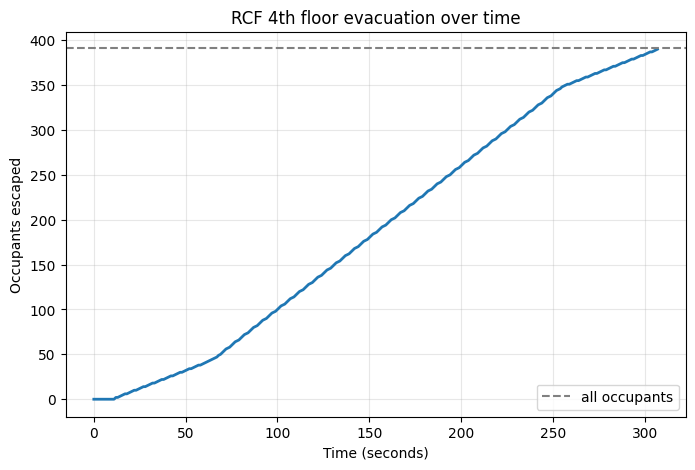

 25% out ( 97 people):   99 sec (1.6 min)
 50% out (195 people):  160 sec (2.7 min)
 75% out (293 people):  221 sec (3.7 min)
 90% out (351 people):  260 sec (4.3 min)
 95% out (371 people):  285 sec (4.8 min)


In [7]:
df = model.datacollector.get_model_vars_dataframe()
plt.figure(figsize=(8, 5))
plt.plot(df.index, df["Escaped"], linewidth=2)
plt.axhline(model.total_occupants, color="gray", linestyle="--", label="all occupants")
plt.xlabel("Time (seconds)"); plt.ylabel("Occupants escaped")
plt.title("RCF 4th floor evacuation over time")
plt.legend(); plt.grid(alpha=0.3); plt.show()

total = model.total_occupants
for pct in [0.25, 0.50, 0.75, 0.90, 0.95, 1.00]:
    target = total * pct
    reached = df[df["Escaped"] >= target]
    if len(reached) > 0:
        step = reached.index[0]
        print(f"{int(pct*100):3d}% out ({int(target):3d} people): {step:4d} sec ({step/60:.1f} min)")

In [8]:
# Run once and report how occupants split between the two stairs.
model = RCFFloorModel(seed=42)
max_steps = 2000
step_count = 0
while model.escaped_count < model.total_occupants and step_count < max_steps:
    model.step()
    step_count += 1

s2 = model.door_escape_count['stair2']
s3 = model.door_escape_count['stair3']
print(f"Total evacuation: {step_count} sec ({step_count/60:.1f} min)")
print(f"Stair 2 used by: {s2} occupants")
print(f"Stair 3 used by: {s3} occupants")
print(f"Split: {s2/(s2+s3)*100:.0f}% Stair 2 / {s3/(s2+s3)*100:.0f}% Stair 3")
print(f"(Hand analysis assumed ~50/50 for the 4th floor)")

# First-principles check: if both doors ran at full 0.8/sec with balanced load,
# 391 / (2 * 0.8) = ~244 sec (~4.1 min). Compare to actual above.
print(f"\nFirst-principles (both doors full, balanced): ~{391/(2*0.8):.0f} sec ({391/(2*0.8)/60:.1f} min)")

Total evacuation: 308 sec (5.1 min)
Stair 2 used by: 195 occupants
Stair 3 used by: 196 occupants
Split: 50% Stair 2 / 50% Stair 3
(Hand analysis assumed ~50/50 for the 4th floor)

First-principles (both doors full, balanced): ~244 sec (4.1 min)


In [9]:
# DIAGNOSTIC: why is Stair 2 never chosen?
# Compute separate distance fields to each stair, then see which is nearer per cell.

stair2_cells = {cell for cell in exits if cell[1] < 30}   # north stair
stair3_cells = {cell for cell in exits if cell[1] >= 30}  # south stair

dist_to_s2 = compute_distance_field(walkable, stair2_cells)
dist_to_s3 = compute_distance_field(walkable, stair3_cells)

# For every spawn cell, which stair is closer?
closer_to_s2 = 0
closer_to_s3 = 0
unreachable_s2 = 0
for cell in (spawn400 | spawn401):
    d2 = dist_to_s2.get(cell, float('inf'))
    d3 = dist_to_s3.get(cell, float('inf'))
    if d2 == float('inf'):
        unreachable_s2 += 1
    if d2 < d3:
        closer_to_s2 += 1
    else:
        closer_to_s3 += 1

print(f"Spawn cells closer to Stair 2: {closer_to_s2}")
print(f"Spawn cells closer to Stair 3: {closer_to_s3}")
print(f"Spawn cells that CAN'T reach Stair 2 at all: {unreachable_s2}")
print()

# Sample a few RCF 400 cells (the far ones) to see the actual distances
print("Sample distances from RCF 400 far corner cells (col, row): d_to_S2 vs d_to_S3")
sample = sorted(spawn400, key=lambda c: -(c[0]+c[1]))[:5]  # farthest SE corner
for cell in sample:
    d2 = dist_to_s2.get(cell, float('inf'))
    d3 = dist_to_s3.get(cell, float('inf'))
    print(f"  cell {cell}: Stair2 = {d2}, Stair3 = {d3}")

Spawn cells closer to Stair 2: 0
Spawn cells closer to Stair 3: 488
Spawn cells that CAN'T reach Stair 2 at all: 0

Sample distances from RCF 400 far corner cells (col, row): d_to_S2 vs d_to_S3
  cell (57, 66): Stair2 = 66, Stair3 = 32
  cell (56, 66): Stair2 = 66, Stair3 = 31
  cell (57, 65): Stair2 = 66, Stair3 = 32
  cell (55, 66): Stair2 = 66, Stair3 = 30
  cell (57, 64): Stair2 = 66, Stair3 = 32


Monte Carlo: 30 runs
Mean evacuation:   5.08 min (305 sec)
Min (best case):   5.02 min
Max (worst case):  5.13 min
Std dev (spread):  1.6 sec


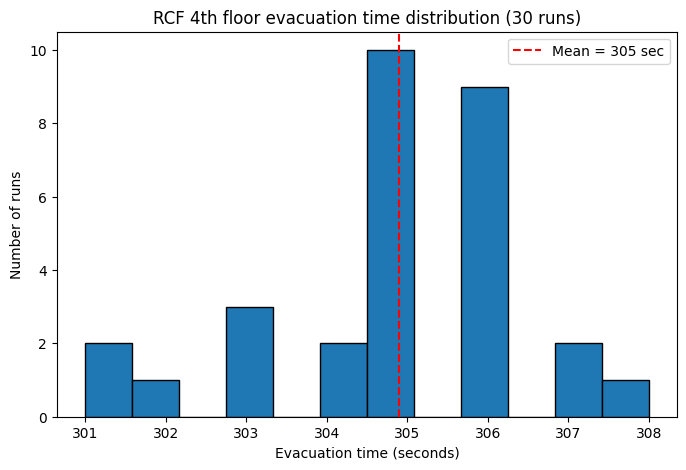

In [10]:
# MONTE CARLO: run many times with different seeds to get a distribution.
import numpy as np

n_runs = 30
evac_times = []

for seed in range(n_runs):
    m = RCFFloorModel(seed=seed)
    steps = 0
    while m.escaped_count < m.total_occupants and steps < 2000:
        m.step()
        steps += 1
    evac_times.append(steps)

evac_times = np.array(evac_times)
evac_minutes = evac_times / 60

print(f"Monte Carlo: {n_runs} runs")
print(f"Mean evacuation:   {evac_minutes.mean():.2f} min ({evac_times.mean():.0f} sec)")
print(f"Min (best case):   {evac_minutes.min():.2f} min")
print(f"Max (worst case):  {evac_minutes.max():.2f} min")
print(f"Std dev (spread):  {evac_times.std():.1f} sec")

# Distribution histogram
plt.figure(figsize=(8, 5))
plt.hist(evac_times, bins=12, edgecolor='black')
plt.axvline(evac_times.mean(), color='red', linestyle='--',
            label=f'Mean = {evac_times.mean():.0f} sec')
plt.xlabel("Evacuation time (seconds)")
plt.ylabel("Number of runs")
plt.title(f"RCF 4th floor evacuation time distribution ({n_runs} runs)")
plt.legend()
plt.show()

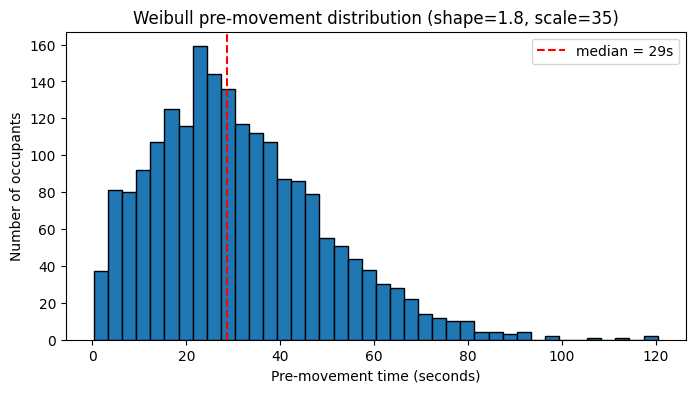

Median: 29s, Mean: 31s, Max: 120s, 90th pct: 56s


In [11]:
# Visualize the pre-movement distribution before running the sim with it.
import numpy as np
import random as _r
rng = _r.Random(0)
samples = [rng.weibullvariate(35.0, 1.8) for _ in range(2000)]
samples = np.array(samples)
plt.figure(figsize=(8, 4))
plt.hist(samples, bins=40, edgecolor='black')
plt.axvline(np.median(samples), color='red', linestyle='--',
            label=f'median = {np.median(samples):.0f}s')
plt.xlabel("Pre-movement time (seconds)")
plt.ylabel("Number of occupants")
plt.title("Weibull pre-movement distribution (shape=1.8, scale=35)")
plt.legend()
plt.show()
print(f"Median: {np.median(samples):.0f}s, Mean: {samples.mean():.0f}s, "
      f"Max: {samples.max():.0f}s, 90th pct: {np.percentile(samples,90):.0f}s")

In [15]:
from mesa.visualization import SolaraViz, make_space_component, make_plot_component

# ----------------------------------------------------------------------
# agent_portrayal: SolaraViz calls this once per on-grid agent each step
# to decide how to draw it. Escaped agents are already removed from the
# grid (Cell 4's remove_agent call), so this never sees them — they just
# vanish from the view, which is the behavior we want.
# ----------------------------------------------------------------------
def agent_portrayal(agent):
    # Color encodes ASSIGNED STAIR — this is the validation we care about.
    # Blue  = routed to Stair 2 (should be the far-west / farthest-from-S3 half)
    # Orange = routed to Stair 3 (the nearer half)
    color = "tab:blue" if agent.target_stair == "stair2" else "tab:orange"

    # Opacity encodes STATE. Still inside the pre-movement (reaction) window?
    # Draw faded. Once moving, draw solid. One glance now shows BOTH
    # "is the split correct" (hue) and "who hasn't started yet" (alpha).
    still_reacting = agent.steps_waited < agent.reaction_delay
    alpha = 0.25 if still_reacting else 1.0

    return {
        "color": color,
        "size": 18,        # smaller than v1's 30 — 391 agents on a 58x67 grid get crowded
        "alpha": alpha,
    }

# ----------------------------------------------------------------------
# post_process: runs on the matplotlib axis AFTER the space is drawn.
# Cell 1 defines row 0 = NORTH with rows increasing southward, but
# matplotlib's y-axis increases UPWARD by default — so without this the
# floor renders upside down. invert_yaxis() puts north back on top,
# matching your NFPA hand-analysis floor plans. We also lock the aspect
# ratio so 1m cells stay square and pin the limits to the real grid.
# ----------------------------------------------------------------------
def post_process(ax):
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.invert_yaxis()              # north up
    ax.set_aspect("equal")         # square cells, true proportions
    ax.set_title("RCF 4th Floor — occupants colored by assigned stair")

# ----------------------------------------------------------------------
# model_params: interactive controls. KEYS MUST MATCH RCFFloorModel's
# __init__ argument names EXACTLY (n_400, n_401) or SolaraViz will error.
# Defaults are your real NFPA occupant loads. Dragging them up lets you
# demo how the 320-capacity bottleneck worsens as load climbs past it.
# ----------------------------------------------------------------------
model_params = {
    "n_400": {
        "type": "SliderInt",
        "value": 304,          # RCF 400 real occupant load
        "min": 50,
        "max": 400,
        "step": 10,
        "label": "RCF 400 occupants (large assembly)",
    },
    "n_401": {
        "type": "SliderInt",
        "value": 87,           # RCF 401 real occupant load
        "min": 20,
        "max": 150,
        "step": 10,
        "label": "RCF 401 occupants (small assembly)",
    },
}

# Fresh model instance for the dashboard.
viz_model = RCFFloorModel(n_400=304, n_401=87)

# ----------------------------------------------------------------------
# Build the dashboard: the space (grid + agents, north-up via post_process)
# and a live "Escaped" curve so you watch the evacuation S-curve form in
# real time. backend="matplotlib" is the right choice for ~391 agents and
# for producing a clean recordable GIF.
# ----------------------------------------------------------------------
page = SolaraViz(
    viz_model,
    components=[
        make_space_component(
            agent_portrayal,
            post_process=post_process,
            backend="matplotlib",
        ),
        make_plot_component("Escaped"),
    ],
    model_params=model_params,
    name="Fire Egress Simulation v2 — RCF 4th Floor",
)
page

Cannot show ipywidgets in text